In [1]:
#Библиотеки
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    average_precision_score,
    precision_recall_curve,
    ConfusionMatrixDisplay)
from sklearn.metrics import confusion_matrix
from sklearn.inspection import permutation_importance
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier


In [2]:
#Загрузим датасет
df = pd.read_csv("train.csv")

#"Чистим" названия столбцов
df.columns = df.columns.str.strip()

#Выведем размер датасета, кол-во дубликатов строк и строк с пропусками
print(f'Размер таблицы до подготовки данных:{df.shape}')
print(f'Количество дубликатов до подготовки = {df.duplicated().sum()}')
print(f'Количество строк с пропусками до подготовки = {df.isna().any(axis=1).sum()}') 

#Проверим фичи - выведем названия, кол-во и % пропусков, типы данных
info = pd.DataFrame({"missing":(df.isna().sum()),
                     "missing_%": (df.isna().mean() * 100).round(2),
                     "dtype": df.dtypes})
print(info.sort_values("missing_%", ascending=False))

# выведем уникальные значения категориальных столбцов и таргета
categorical_columns = ["Self_Employed","Dependents", "Gender", "Married", "Education", "Property_Area", "Loan_Status"]
for col in categorical_columns:
    print(f"\nУникальные {col}:")
    print(df[col].unique().tolist())

#смотрим распределение таргета
print(df["Loan_Status"].value_counts()) 

df.head(5)

Размер таблицы до подготовки данных:(614, 13)
Количество дубликатов до подготовки = 0
Количество строк с пропусками до подготовки = 134
                   missing  missing_%    dtype
Credit_History          50       8.14  float64
Self_Employed           32       5.21      str
LoanAmount              22       3.58  float64
Dependents              15       2.44      str
Loan_Amount_Term        14       2.28  float64
Gender                  13       2.12      str
Married                  3       0.49      str
Education                0       0.00      str
Loan_ID                  0       0.00      str
CoapplicantIncome        0       0.00  float64
ApplicantIncome          0       0.00    int64
Property_Area            0       0.00      str
Loan_Status              0       0.00      str

Уникальные Self_Employed:
['No', 'Yes', nan]

Уникальные Dependents:
['0', '1', '2', '3+', nan]

Уникальные Gender:
['Male', 'Female', nan]

Уникальные Married:
['No', 'Yes', nan]

Уникальные Education:
['

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


Таким образом видим:
- дубликаты отсутствуют
- пропуски присутствуют в 7 столбцах
- 6 категорийных фичей (+таргет), 4 числовых
- распределение таргета примерно 2 к 1

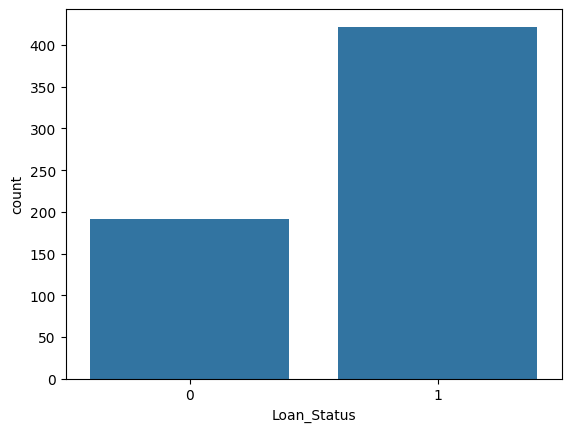

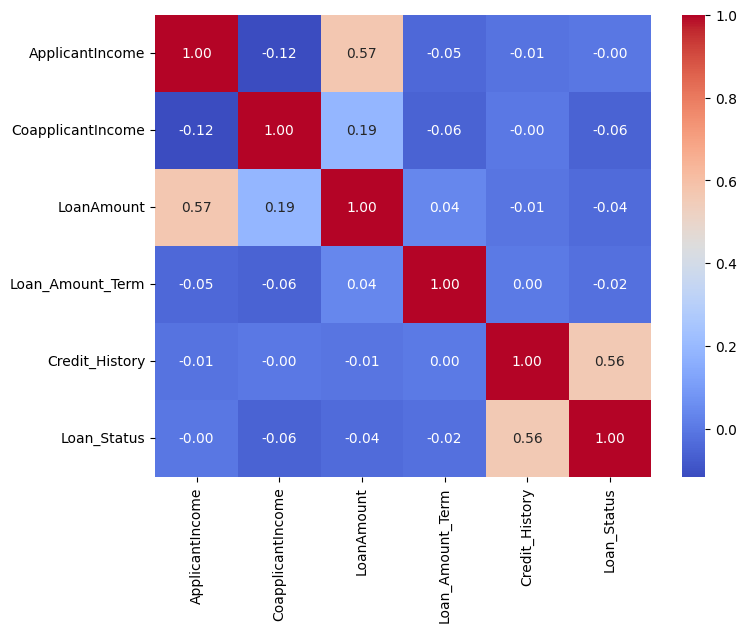

In [3]:
#категорируем таргет
df["Loan_Status"] = np.where(df["Loan_Status"] == "Y", 1, 0)

#удаляем технический столбец
df = df.drop(columns=["Loan_ID"])

#график распределения целевой переменной
sns.countplot(x="Loan_Status", data=df)
plt.show()

#тепловая карта корреляции для числовых признаков 
plt.figure(figsize=(8, 6))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt='.2f')
plt.show()

Из тепловой карты корреляций видим, что на первый взгляд с целевой переменной из числовых фичей коррелирует только кредитная история

Accuracy: 0.756
Precision: 0.840
Recall: 0.800
F1: 0.819


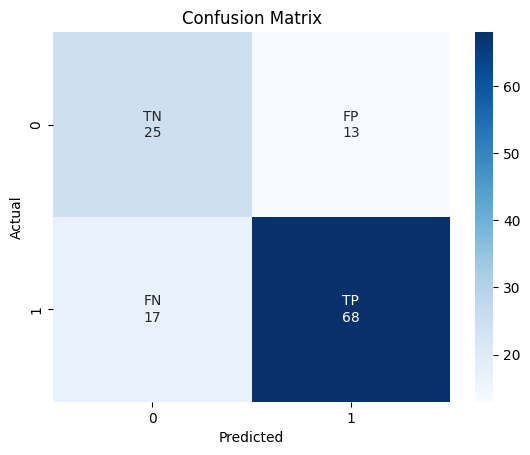

In [4]:
#Создаем препроцессор через ColumnTransformer для заполнения пропусков медианой с индикацией, модой, а также OHE кодирования

numeric_cols = ["Credit_History", "LoanAmount", "Loan_Amount_Term", "ApplicantIncome", "CoapplicantIncome" ]
categorical_cols = ["Self_Employed", "Dependents", "Gender", "Married", "Education", "Property_Area"]

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True))])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))])

preprocessor = ColumnTransformer([
    ("numeric", numeric_transformer, numeric_cols),
    ("categorical", categorical_transformer, categorical_cols)], verbose_feature_names_out=False) #Отключаем добавление приставок categorical/numeric

X = df.drop(columns=["Loan_Status"])     
y = df["Loan_Status"]     

#Разделите данные на train (80%) и test (20%) с stratify по целевой переменной
RANDOM_STATE = 42 #фиксируем случайность
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

#Собираем пайплан из препроцессора и модели решающего дерева
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=42))])

model.fit(X_train, y_train) #обучаем

#Считаем предсказания и метрики
y_pred = model.predict(X_test)

accuracy_bas=accuracy_score(y_test, y_pred)
precision_bas=precision_score(y_test, y_pred)
recall_bas=recall_score(y_test, y_pred)
f1_bas=f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy_bas:.3f}")
print(f"Precision: {precision_bas:.3f}")
print(f"Recall: {recall_bas:.3f}")
print(f"F1: {f1_bas:.3f}")

#Матрица ошибок с графикой
cm = confusion_matrix(y_test, y_pred)
labels = [
    [f"TN\n{cm[0, 0]}", f"FP\n{cm[0, 1]}"],
    [f"FN\n{cm[1, 0]}", f"TP\n{cm[1, 1]}"]]

sns.heatmap(
    cm,
    annot=labels,
    fmt="",
    cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Визуализируем построенное дерево

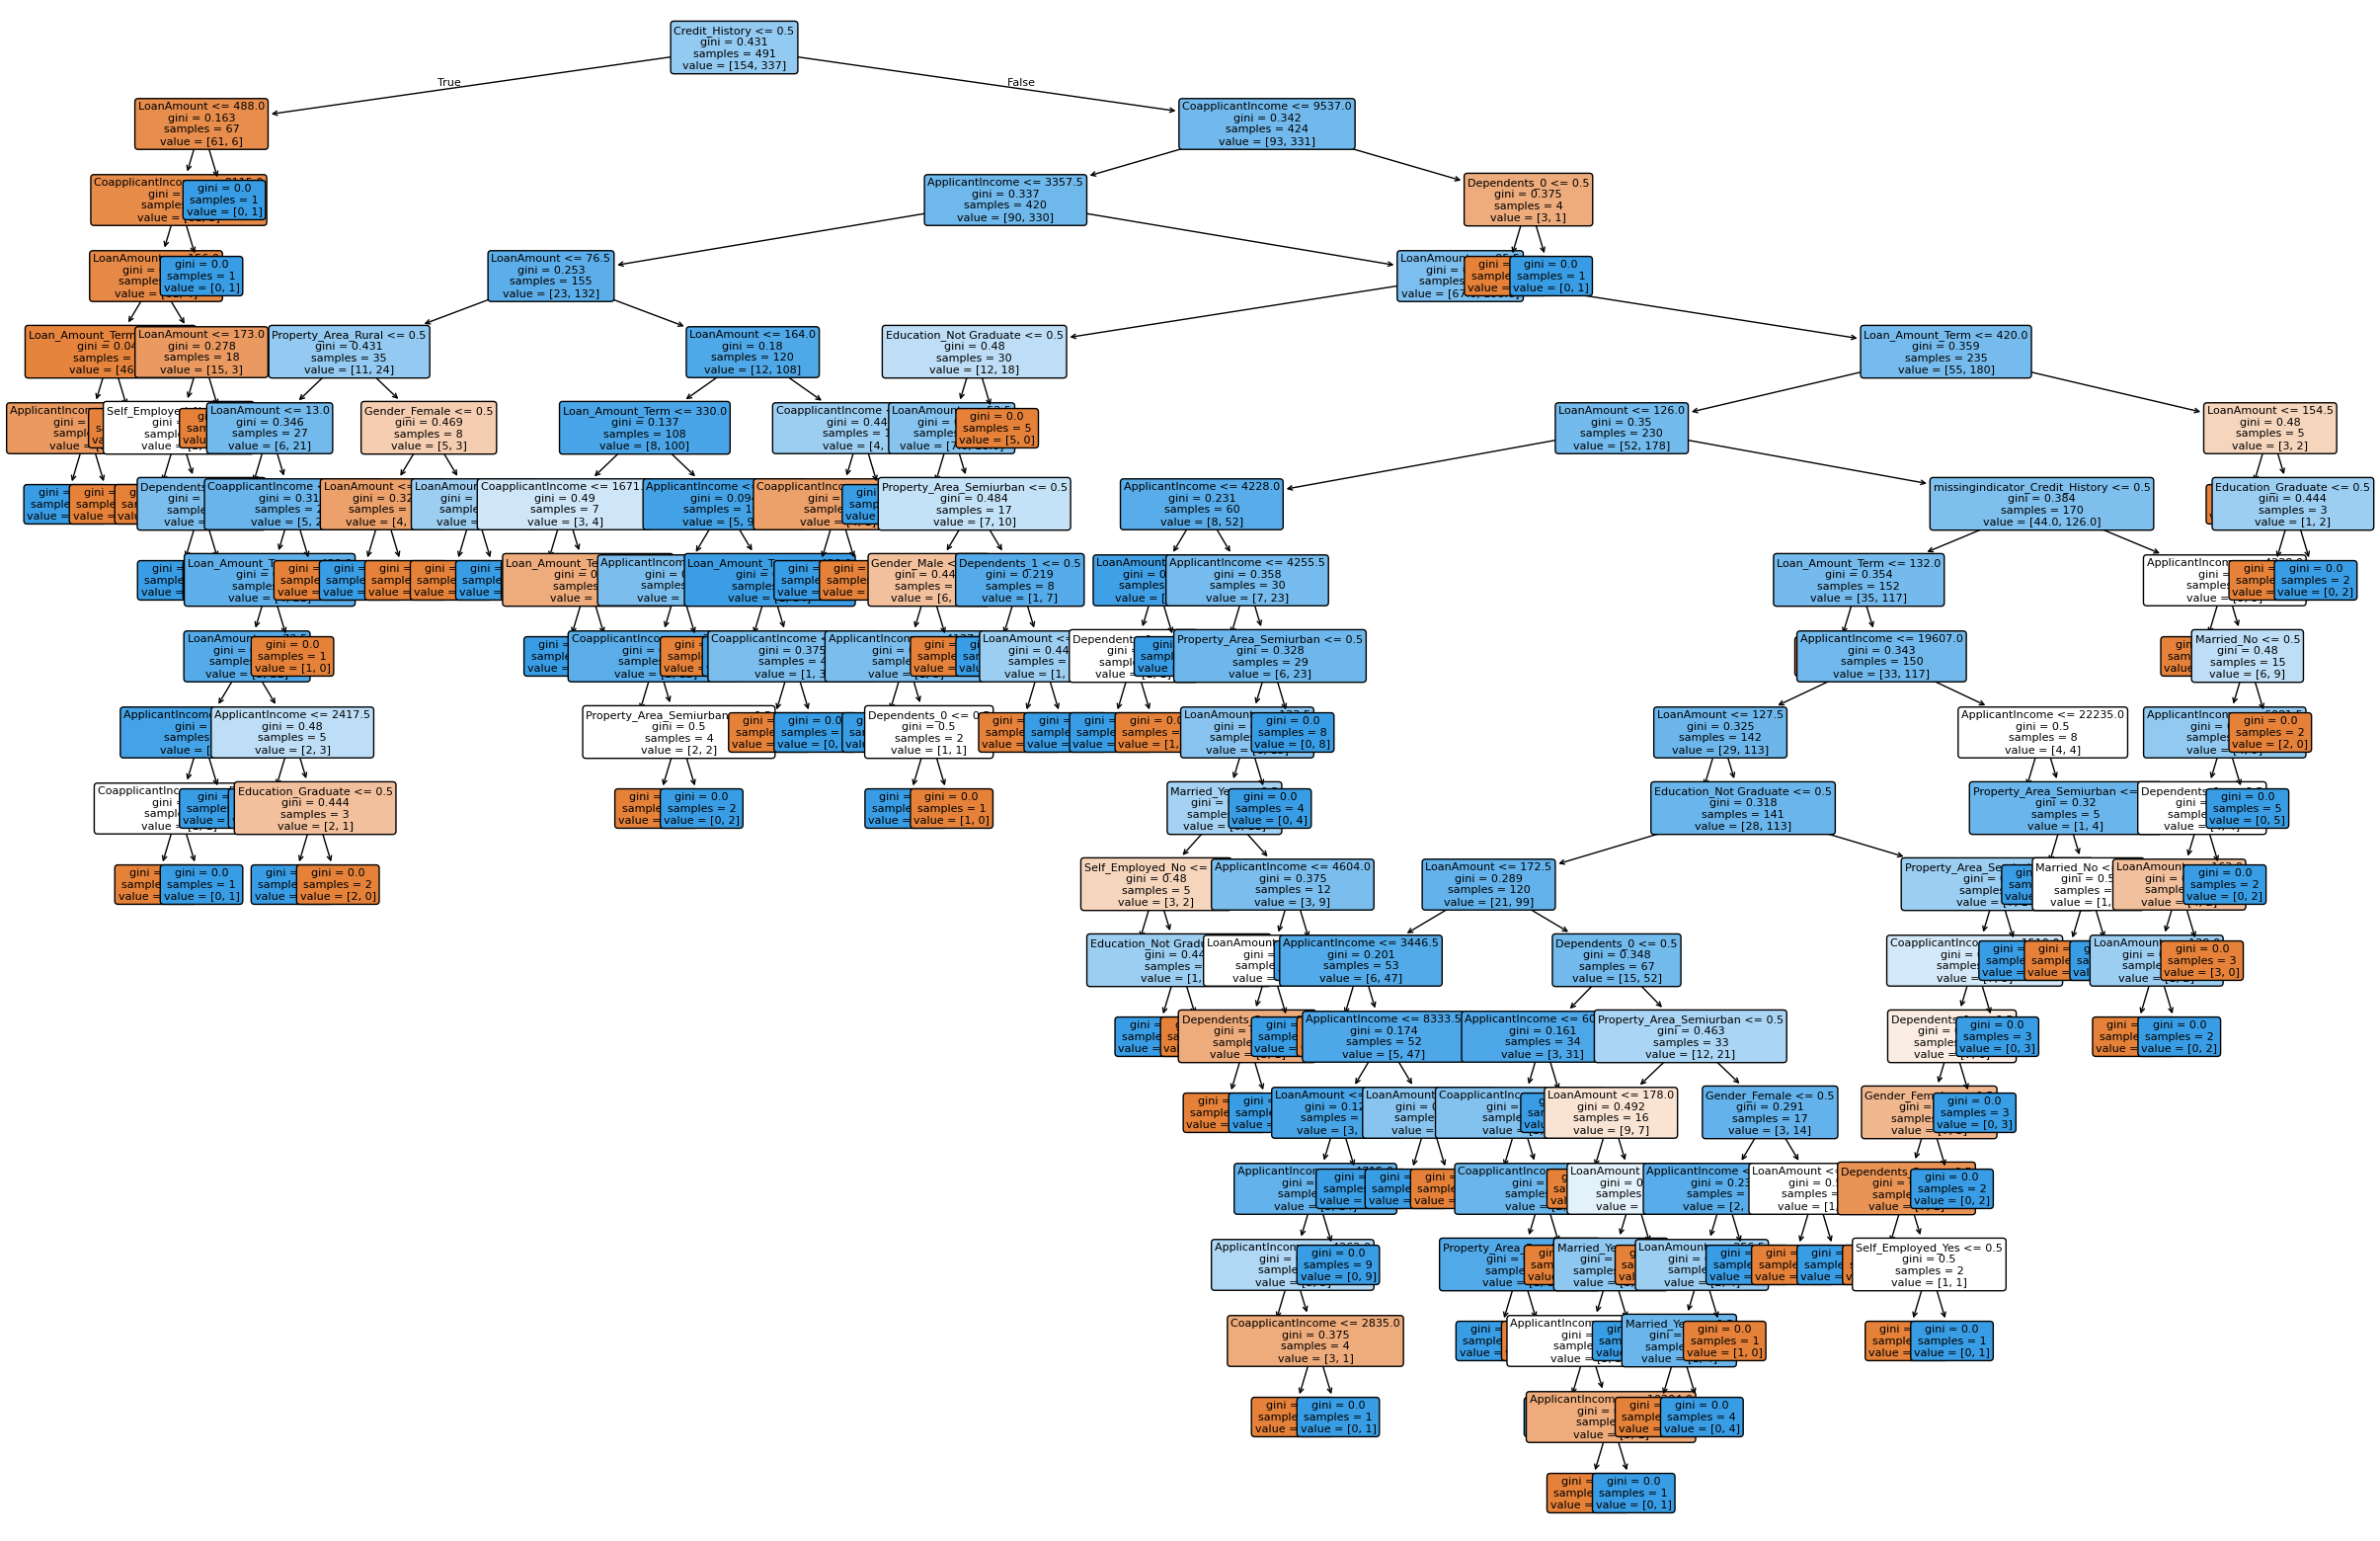

In [5]:
from sklearn.tree import plot_tree

#Для визуализации достанем дерево из пайплайна
tree = model.named_steps["classifier"]

#Назначаем имена фичей (если не применить будут индексы)
feature_names = model.named_steps["preprocessor"].get_feature_names_out()

#Рисуем дерево 
plt.figure(figsize=(30, 20))

plot_tree(
    tree,
    feature_names = feature_names,
    filled=True,
    rounded=True,
    fontsize=8)

plt.show()

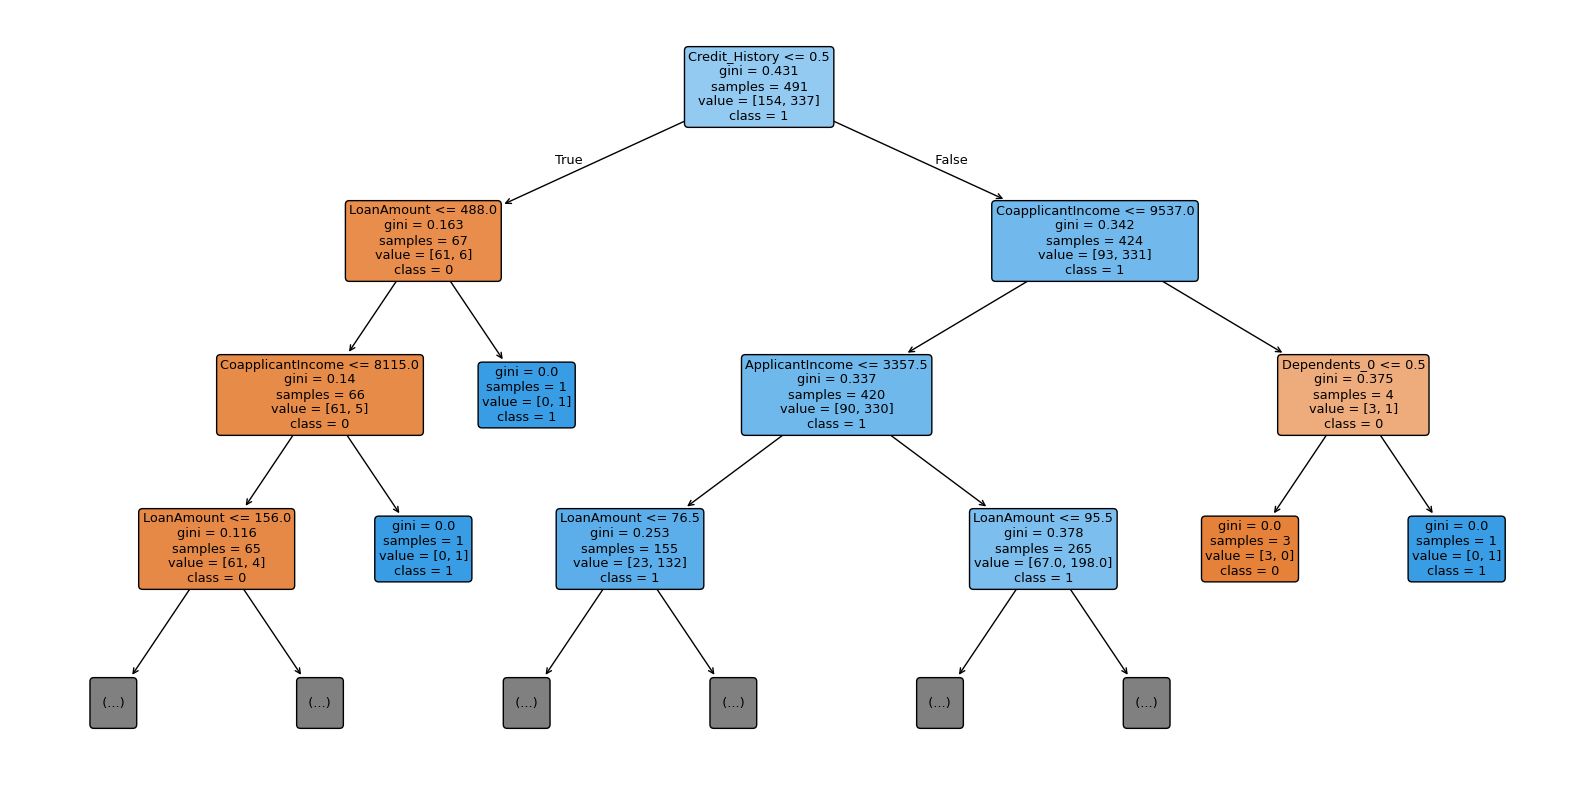

                              feature  importance
0                      Credit_History    0.261446
1                          LoanAmount    0.177818
3                     ApplicantIncome    0.150776
4                   CoapplicantIncome    0.104333
21            Property_Area_Semiurban    0.047049
2                    Loan_Amount_Term    0.044412
10                       Dependents_0    0.035669
19             Education_Not Graduate    0.030982
11                       Dependents_1    0.018976
20                Property_Area_Rural    0.017882
14                      Gender_Female    0.017697
17                        Married_Yes    0.017336
18                 Education_Graduate    0.012614
16                         Married_No    0.012590
8                    Self_Employed_No    0.012141
15                        Gender_Male    0.011826
5     missingindicator_Credit_History    0.011078
13                      Dependents_3+    0.010643
9                   Self_Employed_Yes    0.004730


In [6]:
#Рисуем дерево с ограничением по глубине = 3
plt.figure(figsize=(20, 10))
feature_names = model.named_steps["preprocessor"].get_feature_names_out()
plot_tree(
    tree,
    feature_names = feature_names,
    class_names=["0", "1"],
    filled=True,
    rounded=True,
    max_depth=3)

plt.show()

#Оцениваем значимость фичей
importances = pd.DataFrame({
    "feature": feature_names,
    "importance": tree.feature_importances_})

#Сортируем
importances = importances.sort_values(
    "importance",
    ascending=False)

print(importances)

- Первое разбиение произошло по признаку Кредитная история (порог 0,5)
- Наиболее значимые фичи (топ-5):Credit_History, LoanAmount, ApplicantIncome, CoapplicantIncome и значение категориального признака Property_Area = Semiurban (или после OHE - Property_Area_Semiurban)  
 
Для проверки переобучения сравним полученные метрики с метриками, посчитанными на train 

In [ ]:
#Посчитаем метрики на train данных
y_pred_train = model.predict(X_train)

accuracy_bas_tr=accuracy_score(y_train, y_pred_train)
precision_bas_tr=precision_score(y_train, y_pred_train)
recall_bas_tr=recall_score(y_train, y_pred_train)
f1_bas_tr=f1_score(y_train, y_pred_train)

#Сравним в таблице
metrics = pd.DataFrame({
    "Train": [
        accuracy_bas_tr,
        precision_bas_tr,
        recall_bas_tr,
        f1_bas_tr],
    "Test": [
        accuracy_bas,
        precision_bas,
        recall_bas,
        f1_bas
    ]}, index=["Accuracy", "Precision", "Recall", "F1"])

metrics.round(3)


,Train,Test
Accuracy,1.0,0.756
Precision,1.0,0.840
Recall,1.0,0.800
F1,1.0,0.819


Очевидно имеем переобучение, т.к. дерево идеально подстроилось под тренировочные данные. (все метрики = 1)

Выводы:
1) Дерево максимально интерпретируемо - на любом узле (сплите) - мы видим название фичи, порог, информацию о листьях после данного разбиения, gini листьев, объекты листьев и т.д.
2) Выявленная закономерность: при отсутствии критериев останова - гарантировано переобучение, т.к. модель может бесконечно долго улучшать information gain, находя оптимальные пороги фичей, подстраиваясь даже под шум, пока не получит "чистые" листья, которые могут содержать даже по 1 объекту в листе

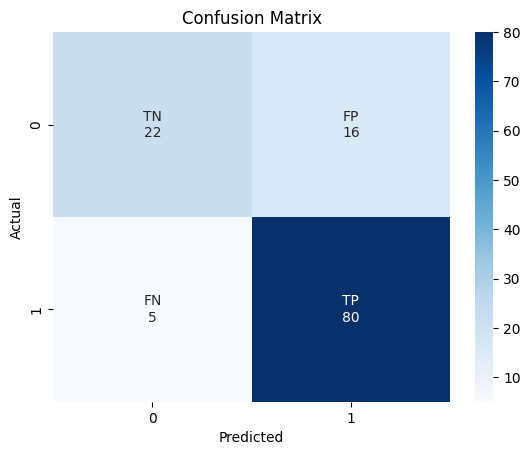

,Long Train,Long Test,Short Test,Short Train
Accuracy,1.0,0.756,0.829,0.811
Precision,1.0,0.840,0.833,0.795
Recall,1.0,0.800,0.941,0.976
F1,1.0,0.819,0.884,0.876


In [ ]:
#Создадим модель с критериями останова (глубина, листья)
model_short = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        random_state=42,
        max_depth=5,
        min_samples_split=20,
        min_samples_leaf=10))])

model_short.fit(X_train, y_train)

y_pred = model_short.predict(X_test)

#Посчитаем метрики на test данных
accuracy_short=accuracy_score(y_test, y_pred)
precision_short=precision_score(y_test, y_pred)
recall_short=recall_score(y_test, y_pred)
f1_short=f1_score(y_test, y_pred)

#Матрица ошибок
cm = confusion_matrix(y_test, y_pred)
labels = [
    [f"TN\n{cm[0, 0]}", f"FP\n{cm[0, 1]}"],
    [f"FN\n{cm[1, 0]}", f"TP\n{cm[1, 1]}"]]

sns.heatmap(
    cm,
    annot=labels,
    fmt="",
    cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

#Посчитаем метрики на train данных
y_pred_train = model_short.predict(X_train)

accuracy_short_tr=accuracy_score(y_train, y_pred_train)
precision_short_tr=precision_score(y_train, y_pred_train)
recall_short_tr=recall_score(y_train, y_pred_train)
f1_short_tr=f1_score(y_train, y_pred_train)

#Сравним в таблице
metrics = pd.DataFrame({
    "Long Train": [
        accuracy_bas_tr,
        precision_bas_tr,
        recall_bas_tr,
        f1_bas_tr],
    "Long Test": [
        accuracy_bas,
        precision_bas,
        recall_bas,
        f1_bas],
    "Short Test": [
            accuracy_short,
            precision_short,
            recall_short,
            f1_short],
    "Short Train": [
                accuracy_short_tr,
                precision_short_tr,
                recall_short_tr,
                f1_short_tr],
        }, index=["Accuracy", "Precision", "Recall", "F1"])

metrics.round(3)

Добавление критериев останова 
- максимальной глубины (5), 
- минимального количества объектов в родительском листе, чтобы его можно было разделить (20),
- минимального количества объектов в дочернем листе (10)  
позволило нам:  
1) избавиться от переобучения (gap между метриками на train и test выборках существенно уменьшился)
2) существенно повысить значения почти всех метрик (Accuracy	0.756 vs 0.829, Recall 0.800 vs 0.941, F1 0.819 vs 0.884). Падение метрики  Precision	при этом несущественное (0.840 vs 0.833)

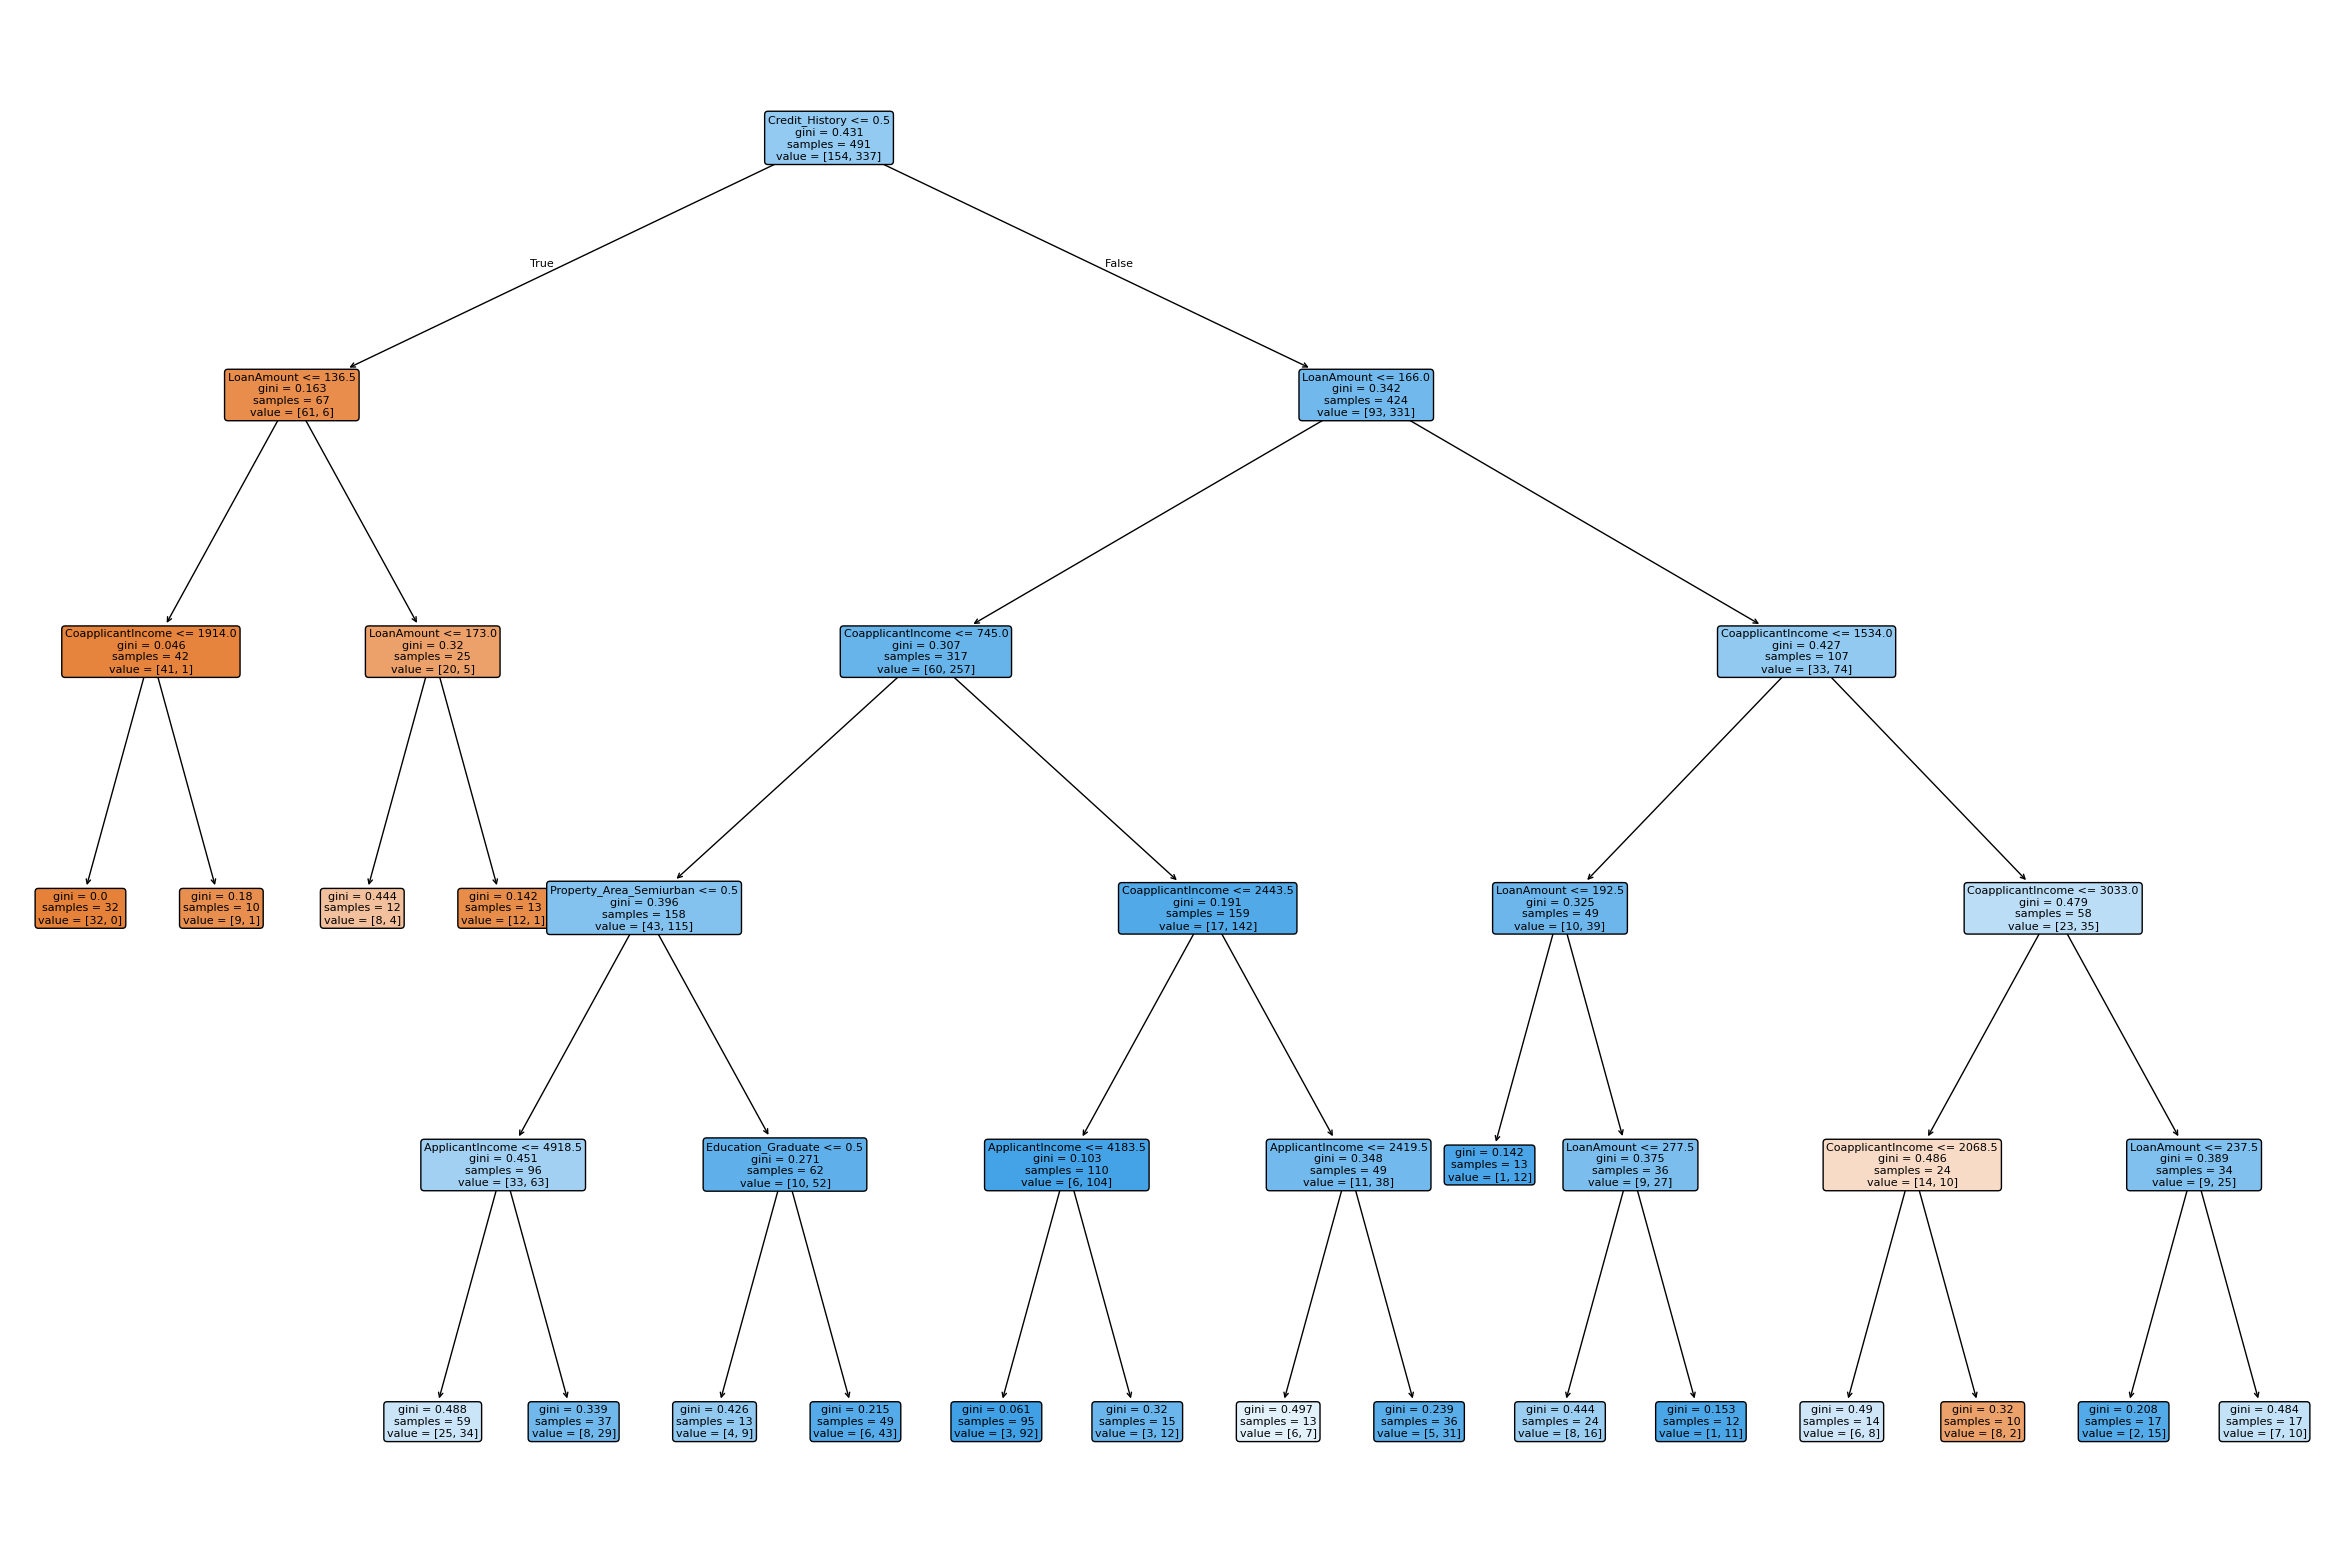

In [9]:
#Достанем дерево из пайплайна
tree = model_short.named_steps["classifier"]
#Назначаем имена фичей (если не применить будут индексы)
feature_names = model_short.named_steps["preprocessor"].get_feature_names_out()
#Рисуем дерево 
plt.figure(figsize=(30, 20))

plot_tree(
    tree,
    feature_names = feature_names,
    filled=True,
    rounded=True,
    fontsize=8)

plt.show()

Визуализация нового решающего дерева показала, что добавление критериев останова значительно упростило наше дерево, снизился разброс (variance). После ограничения дерева листья содержат существенно больше объектов

In [10]:
#Используем GridSearchCV для поиска оптимальных параметров.
from sklearn.model_selection import GridSearchCV

param_grid = {
    "classifier__max_depth": [2, 3, 4, 5, 6, 7, 8, 9, 10, None],
    "classifier__min_samples_split": range(2, 31, 2),
    "classifier__min_samples_leaf": range(1, 21, 2)}

model_grid = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=42))])

grid_search = GridSearchCV(
    estimator=model_grid,
    param_grid=param_grid,
    cv=5, #5 фолдов
    scoring="f1", #за критерий возьмем максимизацию среднего гармонического между Precision и Recall
    n_jobs=-1)  #используем все ядра

grid_search.fit(X_train, y_train)

#Выведем лучшие параметры
print(grid_search.best_params_)

#Берем модель с лучшими параметрами (автоматически уже обучена модель с оптимальной комбинацией гиперпараметров)
best_model = grid_search.best_estimator_

#Рассчитаем метрики на тестовых данных
y_pred_grid = best_model.predict(X_test)

accuracy_grid = accuracy_score(y_test, y_pred_grid)
precision_grid = precision_score(y_test, y_pred_grid)
recall_grid = recall_score(y_test, y_pred_grid)
f1_grid = f1_score(y_test, y_pred_grid)

metrics["Grid Test"] = [
    accuracy_grid,
    precision_grid,
    recall_grid,
    f1_grid]

#Сравним с метриками на трейне (проверка на переобучение)
y_pred_grid_tr = best_model.predict(X_train)

accuracy_grid_tr = accuracy_score(y_train, y_pred_grid_tr)
precision_grid_tr = precision_score(y_train, y_pred_grid_tr)
recall_grid_tr = recall_score(y_train, y_pred_grid_tr)
f1_grid_tr = f1_score(y_train, y_pred_grid_tr)

metrics["Grid Train"] = [
    accuracy_grid_tr,
    precision_grid_tr,
    recall_grid_tr,
    f1_grid_tr]

metrics.round(3)

{'classifier__max_depth': 2, 'classifier__min_samples_leaf': 9, 'classifier__min_samples_split': 2}


,Long Train,Long Test,Short Test,Short Train,Grid Test,Grid Train
Accuracy,1.0,0.756,0.829,0.811,0.854,0.798
Precision,1.0,0.840,0.833,0.795,0.832,0.781
Recall,1.0,0.800,0.941,0.976,0.988,0.982
F1,1.0,0.819,0.884,0.876,0.903,0.870


С помощью GridSearchCV определили оптимальные значения параметров 
- 'classifier__max_depth': 2 
- 'classifier__min_samples_leaf': 9 
- 'classifier__min_samples_split': 2  

Однако мы все равно задали определенный диапазон выбора гиперпараметров + задали шаг движения внутри данного диапазона, а не перебирали ВСЕвозможные комбинации. Необходимо отметить, что код ячейки выполнялся почти 4 минуты, хотя датасет довольно небольшой, и из-за этого мы должны помнить об иных методах подбора гиперпараметров (RandomSearch, Optuna)  

Можем наблюдать, что модель с оптимальной комбинацией гиперпараметров имеет не только более высокую F1, но и Accuracy, Recall по сравнению с прошлой моделью с заданными критериями останова (Precision получился ниже всего на 0,001) 

          Feature  Importance
0  Credit_History    0.944561
1      LoanAmount    0.055439


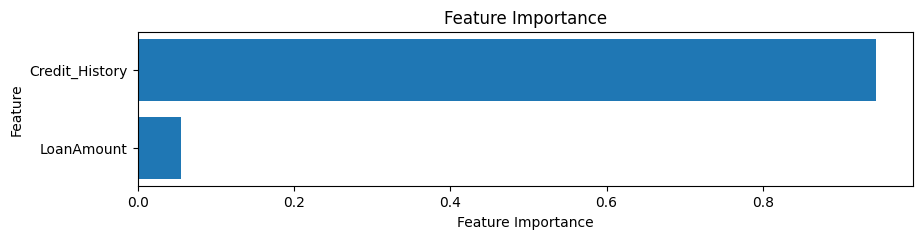

In [11]:
#Проведем анализ важности признаков для оптимизированной модели
best_tree = best_model.named_steps["classifier"] #обращаемся к конкретному этапу Pipeline, достаем модель

feature_names = best_model.named_steps["preprocessor"].get_feature_names_out() #Возвращаем названия признаков, которые получились после препроцессинга

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": best_tree.feature_importances_}).sort_values("Importance", ascending=True)


#Печатаем ненулевые важности
print(feature_importance[feature_importance["Importance"] != 0].sort_values("Importance", ascending=False))

#Строим график для ненулевых важностей
feature_importance_nonzero = feature_importance[feature_importance["Importance"] != 0] #чистим датафрейм от нулевых важностей

plt.figure(figsize=(10, 2))

plt.barh(
    feature_importance_nonzero["Feature"],
    feature_importance_nonzero["Importance"])

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Feature Importance")

plt.show()

Наше решающее дерево брало за основу всего 2 признака из 19. Выглядит странно, однако если мы вспомним, что его оптимальная глубина = 2, то это звучит гораздо логичнее. Проверим через Permutation Importance

          Feature  Importance
0  Credit_History    0.149462


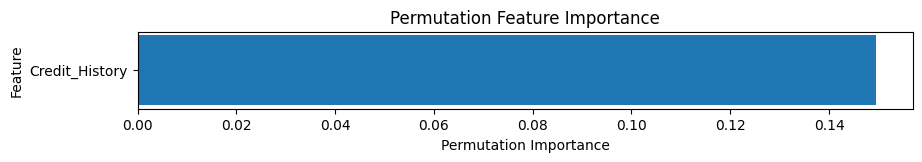

In [12]:
X_test_transformed = best_model.named_steps["preprocessor"].transform(X_test) #Получаем данные после препроцессинга

#Применяем Permutation Importance
perm_importance = permutation_importance(
    best_tree,
    X_test_transformed,
    y_test,
    scoring="f1",  #критерий оценки важности - f1
    n_repeats=30,  #30 повторений перемешивания
    random_state=42)

feature_names = best_model.named_steps["preprocessor"].get_feature_names_out() #Достаем названия фичей после препроцессинга

#Создаем датафрейм из значений важности фичей по методу Permutation Importance
perm_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": perm_importance.importances_mean
}).sort_values("Importance", ascending=False)

#Печатаем ненулевые важности
print(perm_df[perm_df["Importance"] != 0])

#Строим график для ненулевых важностей
perm_df_nonzero = perm_df[perm_df["Importance"] != 0] #чистим датафрейм от нулевых важностей

plt.figure(figsize=(10, 1))
plt.barh(
    perm_df_nonzero["Feature"],
    perm_df_nonzero["Importance"])
plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.title("Permutation Feature Importance")
plt.gca().invert_yaxis()
plt.show()

Получили очень интересный результат. Метод Permutation Importance показал важность только одного признака - Credit History. Делаю следующий вывод:   
Это связано с тем, что решающее дерево при каждом сплите берет за основу критерий максимального information gain или максимального уменьшения критерия Джини (от родительского листа к дочернему). А метод permutation feature берет за основу критерий F1-score, то есть ему не важна "жадность" в моменте на сплите, для него главное - итог.   
Прошу дать обратную связь, верный ли я сформулировал вывод

Для предсказания одобрения кредитной заявки с точки зрения оптимизации метрики F1-score, единственно важным признаком оказалась Кредитная история. Однако наше дерево в моменте с целью оптимизации разбиений данных в сплите использовало помимо кредитной истории еще Сумму кредита.   
Изменение гиперпараметров, в частности, подбор гиперпараметров с помощью GridSearchCV, позволил выбрать оптимальную комбинацию этих параметров, в связи с чем модель стала гораздо более легко интерпретируема, проста, а также повысились все ее метрики оценки качества. При этом проверка показала, что переобучения не возникло (за счет кросс валидации). 
При решении данной задачи появились преимущества в виде довольно низкого смещения (bias), однако появился и недостаток в виде высокого разброса (variance). Для решения данной проблемы пришлось подбирать гиперпараметры, а также использовать кросс-валидацию, тем самым мы выявили оптимальный компромисс, приняв за критерий оценки метрику f1